<a href="https://colab.research.google.com/github/Jiya936/makeup_exam/blob/main/makeup_pe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk scikit-learn matplotlib seaborn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re
warnings.filterwarnings("ignore")

In [ ]:
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)

from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models                 import Sequential
from tensorflow.keras.layers                 import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks              import EarlyStopping

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
toxic_comments = [
    "you are completely useless","nobody likes you","go die in a hole","you are so stupid",
    "shut up idiot","you are a waste of space","you make me sick","i hate you so much",
    "get lost loser","you are pathetic","you are the worst person ever","nobody wants you here",
    "you are absolutely disgusting","drop dead already","you are brain dead",
    "you are a complete failure","eat dirt moron","you are trash","shut your mouth fool",
    "you are an embarrassment","get out of here you freak","i will destroy you",
    "you are a joke","you repulse me","you belong in a trash can",
    "i wish you were never born","you are nothing","go to hell",
    "you disgust everyone","you are absolutely worthless","you piece of garbage",
    "go away and never come back","you are an abomination","i loathe you",
    "you are a coward","you are absolutely horrible","i hope bad things happen to you",
    "you are a leech","you are hateful garbage","you are a monster",
    "you are a parasite","you are disgusting filth","i hate everything about you",
    "you are a complete waste","you are spineless and weak","you will never be good enough",
    "you are repulsive","you are a disgrace","your kind should not exist",
    "you are a worthless nobody","you make everyone miserable","you are vile and disgusting",
    "nobody respects you","you are human garbage","you are a psycho",
    "you are an absolute clown","you are beyond worthless","you are a lowlife scum",
    "nobody cares about your opinion","you are mentally broken","shut up you moron",
    "you are a sad pathetic loser","you are good for nothing","die already you pest",
    "nobody wants you around","you make this world a worse place","you are a horrible human being",
    "get out of my sight forever","you are a wretched person","i cannot stand you",
    "you are revolting","everything about you is wrong","you are intolerable",
    "you are a burden on everyone","people hate being around you","you are truly awful",
    "you should be ashamed of yourself","you are a menace","you are absolutely terrible",
    "you have no redeeming qualities","you are a complete disaster","nobody wants to deal with you",
    "you are repugnant","you are a total failure","you are utterly disgusting",
    "you are beyond help","you are a lost cause","you are worthless to everyone",
    "you are a vile human being","you are despicable","i despise everything you stand for",
    "you should disappear","nobody would miss you","you are morally bankrupt",
    "stop talking you are embarrassing yourself","your opinion means nothing to anyone",
    "you are the dumbest person i have ever met","i regret ever knowing you",
    "you are a stain on humanity","you are absolutely reprehensible","you are a disease",
    "your presence makes everything worse","you are a complete and utter failure",
    "i have never met someone as awful as you","you make people uncomfortable",
    "you are the reason people lose faith in humanity","your existence is a mistake",
    "you are a toxic presence","everyone secretly hates you","you are beyond redemption",
    "you are a disgrace to your family","you bring nothing good to the world",
    "you are the worst thing that ever happened to this community",
    "nobody wants to be near you","you are a complete waste of oxygen",
    "you are a nightmare to deal with","you make everyone around you miserable",
    "i feel sick whenever i see your name","you are a genuinely terrible person",
    "you are irredeemably awful",
    "everything you do is wrong","you are a blight on this community",
    "you are the most annoying person here","you should not be allowed to speak",
    "your words have no value","you are a complete joke","you are truly beneath contempt",
    "you are a sorry excuse for a person","i pity anyone who has to deal with you",
    "you are a waste of everyone's energy","you contribute nothing positive",
    "you are an absolute embarrassment","you are genuinely awful in every way",
    "i cannot believe how terrible you are","you are the worst person i know",
    "you are a catastrophically bad human being","you are despised by everyone",
    "your existence irritates everyone",
    "you are the definition of worthless","you are hopelessly incompetent",
]

nontoxic_comments = [
    "you are amazing","great work on the project","thank you for helping me",
    "well done keep it up","i love your creativity","this is really helpful thanks",
    "excellent explanation","keep up the good work","your ideas are brilliant",
    "nice job everyone","i enjoy working with you","this is a great contribution",
    "thanks for sharing your thoughts","very informative post","i really like your approach",
    "such a thoughtful response","happy to have you in the team","your passion inspires me",
    "good morning everyone","this community is wonderful","i admire your dedication",
    "love the positive energy here","let us work together on this","proud of your achievement",
    "your feedback is very valuable","well explained thank you","beautiful work on this project",
    "you have grown so much","always happy to help","your support means a lot",
    "i value your opinion","keep smiling and stay positive","wishing you all the best",
    "thank you for being kind","great sense of humor","your story touched my heart",
    "i believe in your potential","such a warm community","you are doing amazing things",
    "really appreciate your honesty","congratulations on your success","so glad you shared this",
    "i respect your perspective","this made my day better","you are a wonderful person",
    "thank you for your kindness","always a pleasure to chat","love the positivity here",
    "i am grateful for your help","your smile brightens the room","you handled that really well",
    "fantastic teamwork","your creativity is unmatched","so proud of what you have done",
    "your journey is inspiring","this is outstanding work","you are full of potential",
    "your effort really shows","your work is top notch","you bring out the best in others",
    "really glad you joined us","you are a true leader","you make this place better",
    "your positivity is contagious","you did a fantastic job","you should be very proud",
    "you are so good at explaining things","really enjoyed reading this",
    "you always bring great ideas","keep being the amazing person you are",
    "you are a ray of sunshine","your contributions are truly valued",
    "you have a gift for this","you did really well today","your words carry real meaning",
    "you are such a caring person","i genuinely enjoy your company",
    "you make the world a better place","your insight is always on point",
    "your hard work is paying off","you truly care about others","your enthusiasm is wonderful",
    "your growth has been incredible","i am so glad you are part of this",
    "you are incredibly kind","your help today was invaluable","i appreciate everything you do",
    "you always go above and beyond","what a wonderful perspective",
    "you are a great team player","your advice really helped me",
    "i feel so supported by you","thank you for your patience","you are one in a million",
    "you inspire everyone around you","your kindness is infectious","so happy to know you",
    "you are a positive force","your work speaks for itself","you make everything better",
    "this is exactly the kind of help i needed","i love how you think about problems",
    "your enthusiasm makes everything more fun","you are so easy to work with",
    "i love the way you explain things","your positive attitude is refreshing",
    "you always know the right thing to say","i appreciate how much effort you put in",
    "you are a genuinely good person","the world needs more people like you",
    "you have such a calming presence","your feedback always improves my work",
    "i feel motivated whenever i talk to you","you are an excellent communicator",
    "your thoughtfulness never goes unnoticed","i am lucky to have you on my side",
    "you handle everything with so much grace","your perspective always adds so much value",
    "you are someone i truly look up to","your work makes a real difference",
    "i love collaborating with you","you have such a generous spirit",
    "your commitment to quality is impressive","you are a joy to be around",
    "i always leave conversations with you feeling inspired",
    "you bring out the best in the people around you",
    "your passion for what you do is truly admirable",
    "you are one of the most thoughtful people i know",
    "working with you has been such a great experience",
    "i really value the friendship we have built",
    "you did a great job", "you are an amazing person",
    "such a lovely day", "i trust you the most", "i like you",
    "i feel happy around you", "you are one in billions",
    "your parents would be so proud", "you make everyone around you happy",
    "i love the way you talk"
]

print(f"Toxic     : {len(toxic_comments)}")
print(f"Non-Toxic : {len(nontoxic_comments)}")
assert len(toxic_comments) == len(nontoxic_comments), f"Mismatch! {len(toxic_comments)} vs {len(nontoxic_comments)}"

comments = toxic_comments + nontoxic_comments
labels   = ["Toxic"] * len(toxic_comments) + ["Non-Toxic"] * len(nontoxic_comments)

df = pd.DataFrame({"comment": comments, "label": labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.to_csv("toxic_comments.csv", index=False)

print(f"✅ Dataset: {len(df)} records")
print(df["label"].value_counts().to_string())


Toxic     : 140
Non-Toxic : 140
✅ Dataset: 280 records
label
Toxic        140
Non-Toxic    140


In [ ]:
import re
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

MAX_WORDS = 3000
MAX_LEN   = 20   # our sentences are short, 20 tokens is enough

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text   # NO stopword removal — "useless","amazing" must survive

df["clean"] = df["comment"].apply(clean_text)

print("Sample cleaned:")
for o, c in zip(df["comment"].head(3), df["clean"].head(3)):
    print(f"  {o}  →  {c}")

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean"])
sequences = tokenizer.texts_to_sequences(df["clean"])
padded    = pad_sequences(sequences, maxlen=MAX_LEN, padding="pre", truncating="post")

le = LabelEncoder()
y  = le.fit_transform(df["label"])

print(f"\nVocabulary size : {len(tokenizer.word_index)}")
print(f"Padded shape    : {padded.shape}")
print(f"Label mapping   : {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(" Preprocessing done!")

Sample cleaned:
  i loathe you  →  i loathe you
  everyone secretly hates you  →  everyone secretly hates you
  this is exactly the kind of help i needed  →  this is exactly the kind of help i needed

Vocabulary size : 436
Padded shape    : (280, 20)
Label mapping   : {'Non-Toxic': np.int64(0), 'Toxic': np.int64(1)}
 Preprocessing done!


In [ ]:
# ──────────────────────────────────────────────────────────
# CELL 5 (FINAL FIX) — LSTM using Functional API
# Forces model to build correctly on all TF versions
# ──────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.backend import clear_session
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

clear_session()

X_train, X_test, y_train, y_test = train_test_split(
    padded, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {len(X_train)}  |  Test : {len(X_test)}")

# Functional API — forces build immediately with known input shape
inputs  = Input(shape=(MAX_LEN,))
# Update your Embedding layer to include mask_zero=True
x = Embedding(input_dim=MAX_WORDS, output_dim=64, mask_zero=True)(inputs)
x       = SpatialDropout1D(0.2)(x)
x       = LSTM(64, dropout=0.2, recurrent_dropout=0.2)(x)
x       = Dense(32, activation="relu")(x)
x       = Dropout(0.3)(x)
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()  # ← must show real param counts now

# Update your Embedding layer to include mask_zero=True
# Change patience from 5 to 15
early_stop = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n Test Accuracy : {acc*100:.2f}%")
print(f" Test Loss     : {loss:.4f}")

Train : 224  |  Test : 56


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 20, 64)    │    192,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 20, 64)    │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 20)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     33,024 │ spatial_dropout1… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 227,137 (887.25 KB)

 Trainable params: 227,137 (887.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - accuracy: 0.4826 - loss: 0.6932 - val_accuracy: 0.6522 - val_loss: 0.6874
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5473 - loss: 0.6886 - val_accuracy: 0.6957 - val_loss: 0.6831
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6269 - loss: 0.6779 - val_accuracy: 0.7826 - val_loss: 0.6722
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7711 - loss: 0.6586 - val_accuracy: 0.6957 - val_loss: 0.6541
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8109 - loss: 0.6165 - val_accuracy: 0.7391 - val_loss: 0.6115
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8159 - loss: 0.5522 - val_accuracy: 0.7391 - val_loss: 0.5645
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8557 - loss: 0.4781 - val_accuracy: 0.6957 - val_loss: 0.5600
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8905 - loss: 0.3843 - val_accuracy: 0.6957 - val_loss: 0.596

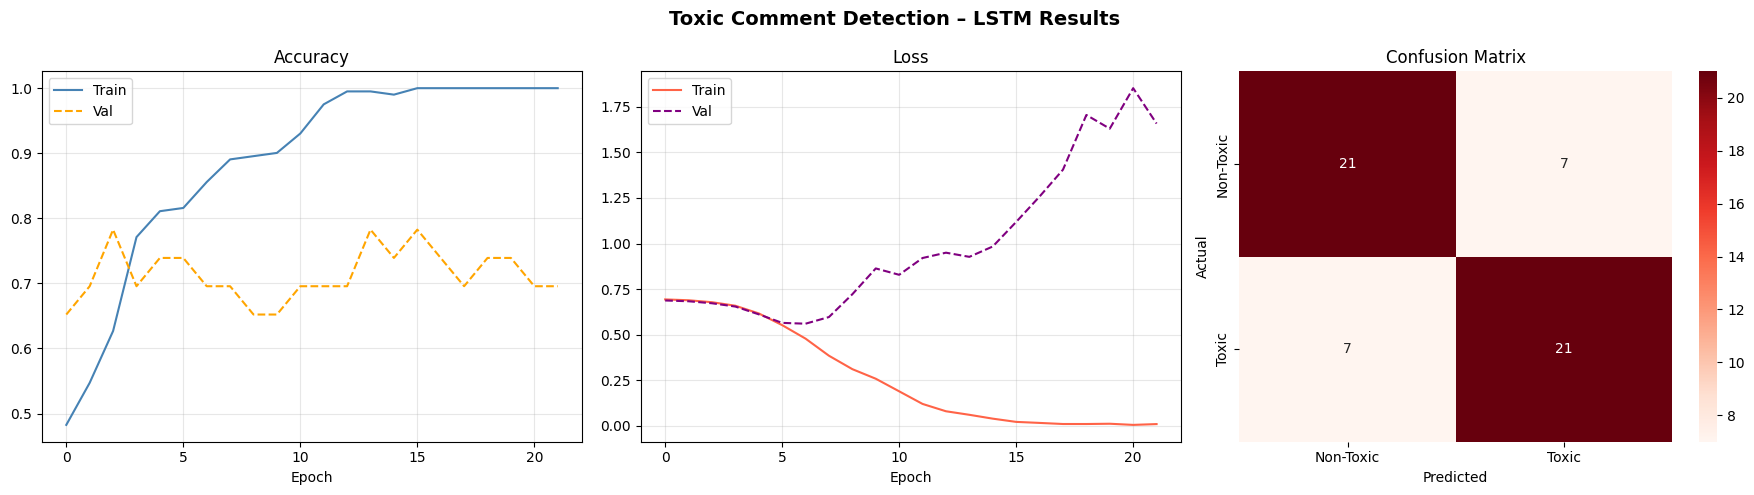


Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.75      0.75      0.75        28
       Toxic       0.75      0.75      0.75        28

    accuracy                           0.75        56
   macro avg       0.75      0.75      0.75        56
weighted avg       0.75      0.75      0.75        56



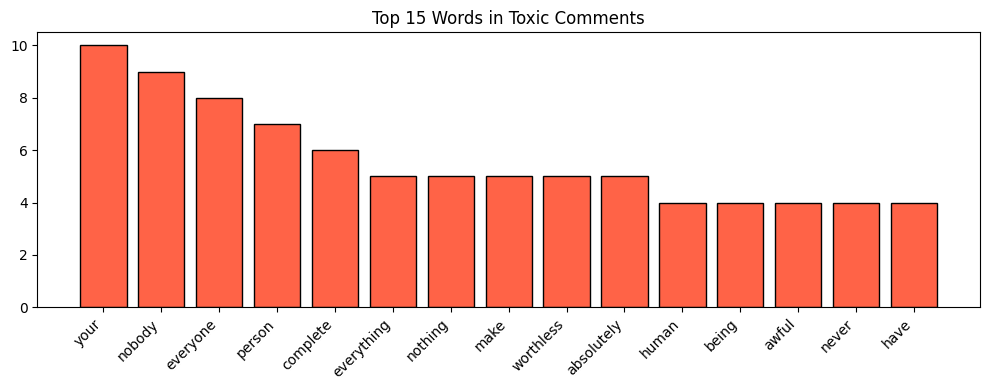

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Toxic Comment Detection – LSTM Results", fontsize=14, fontweight="bold")

axes[0].plot(history.history["accuracy"],     label="Train", color="steelblue")
axes[0].plot(history.history["val_accuracy"], label="Val",   color="orange", linestyle="--")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"],     label="Train", color="tomato")
axes[1].plot(history.history["val_loss"], label="Val",   color="purple", linestyle="--")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

y_pred = (model.predict(X_test, verbose=0) >= 0.5).astype(int).flatten()
cm     = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[2])
axes[2].set_title("Confusion Matrix"); axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Toxic word frequency
from collections import Counter
toxic_text = " ".join(df[df["label"] == "Toxic"]["comment"].str.lower())
toxic_text = re.sub(r"[^a-z\s]", "", toxic_text)
words      = [w for w in toxic_text.split() if len(w) > 3]
top_words  = Counter(words).most_common(15)
wds, cnts  = zip(*top_words)
plt.figure(figsize=(10, 4))
plt.bar(wds, cnts, color="tomato", edgecolor="black")
plt.title("Top 15 Words in Toxic Comments")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
def predict(comment):
    cleaned = clean_text(comment)
    seq     = tokenizer.texts_to_sequences([cleaned])
    pad     = pad_sequences(seq, maxlen=MAX_LEN, padding="pre")
    prob    = model.predict(pad, verbose=0)[0][0]
    label   = "Toxic" if prob >= 0.5 else "Non-Toxic"
    conf    = prob * 100 if label == "Toxic" else (1 - prob) * 100
    # icon    = "🚨" if label == "Toxic" else "✅"
    print(f"\n  Comment : {comment}")
    print(f" Result  : {label}  (confidence: {conf:.1f}%)")

predict("You are completely useless")
predict("I really appreciate your effort")
predict("Nobody likes you here")
predict("Great job on the presentation!")
predict("You are a waste of space")
predict("I love how kind you are")

user_comment = input("\nEnter your comment: ")
predict(user_comment)


  Comment : You are completely useless
 Result  : Toxic  (confidence: 76.3%)

  Comment : I really appreciate your effort
 Result  : Non-Toxic  (confidence: 69.9%)

  Comment : Nobody likes you here
 Result  : Toxic  (confidence: 77.1%)

  Comment : Great job on the presentation!
 Result  : Non-Toxic  (confidence: 69.3%)

  Comment : You are a waste of space
 Result  : Toxic  (confidence: 88.6%)

  Comment : I love how kind you are
 Result  : Non-Toxic  (confidence: 64.1%)

Enter your comment: Complete bullshit

  Comment : Complete bullshit
 Result  : Toxic  (confidence: 57.1%)
